In [3]:
import pickle
import numpy as np 
import re 
from pathlib import Path
import pandas as pd
import json 
%matplotlib inline 

import matplotlib.pyplot as plt 
import seaborn as sns
from src import util_analysis 

# from matplotlib.ticker import FormatStrFormatter

import re 

/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


## Plot results from Popham-style conditions using SWC stimuli

### Import human data

In [4]:
path_to_human_data = Path('/mindhive/mcdermott/www/imgriff/msjspsych/')
# !ls {path_to_human_data}
# full paths to .json files 
human_fnames = list(path_to_human_data.glob("cocktail_party_popham_swc_word_recognition/data/*.json"))

# import vocab dict for matching audio & responses 
# word_and_speaker_encodings = pickle.load( open("/om2/user/imgriff/projects/Auditory-Attention/word_and_speaker_encodings_jsinv3.pckl", "rb" )) 
# # ix_to_word_map = {v:k for k,v in class_map.items()}
# class_map = word_and_speaker_encodings['word_idx_to_word']
len(human_fnames)


236

## Process Human Results

In [5]:
## Get all subject data into one df for analysis

def get_part_df(fname):
    part_data = json.load(open(fname, 'r'))
    # print(f"{fname.stem} success {part_data[0]['success']}")
    part_df = pd.DataFrame.from_records(part_data)
    ## Forward fill stim presentation entry to word response entry
    responses = part_df.loc[part_df.trial_type.isin(['audio-keyboard-response','dictionary-text']), ['trial_index', 'stimulus']]
    responses = responses.ffill()
    part_df.loc[part_df['trial_index'].isin(responses["trial_index"].values), 'stimulus'] = responses.stimulus
    return part_df

dfs = []
for fname in human_fnames:
    try:
        dfs.append(get_part_df(fname))
    except Exception as e:
        print(e)
        print(fname)
    
# results_df = pd.concat([get_part_df(fname) for fname in human_fnames], axis=0, ignore_index=True)
results_df = pd.concat(dfs)

## Filter for those who passed headphone check 
results_df = results_df[results_df.hc_passed == True]


## Add snr and condition names as columns - unpack from file code in file names 

import re
### Get condition map
with open('swc_popham_exmpt_2024_cond_manifest.pkl', 'rb') as f:
    stim_cond_map = pickle.load(f)

stim_cond_map = {f"condition_{k:02}": v for k,v in stim_cond_map.items()}

## Map wav str to stim_type using condition dict
def get_stim_snr_and_cond(stim_str, stim_cond_map=stim_cond_map):
    target_harm, dist_harm = None,  None 
    if isinstance(stim_str, str) and not stim_str.startswith('<'):
        # print(stim_str)
        cond_str = re.search("condition_(-?\d+)", stim_str)
        if cond_str:
            cond_str = cond_str.group(0)
            target_harm = stim_cond_map[cond_str]['target_harmonicity']
            dist_harm = stim_cond_map[cond_str]['distractor_harmonicity']
            if dist_harm is None:
                dist_harm = 'No Distractor'
            target_harm = target_harm.title()
            dist_harm = dist_harm.title()
        elif 'catch' in stim_str:
            target_harm = 'catch_trial'
            dist_harm = 'No Distractor'
    return target_harm, dist_harm

# add as columns 
results_df['target_harmonicity'], results_df['distractor_harmonicity'] = zip(*results_df['stimulus'].apply(get_stim_snr_and_cond))

# cut down df to only have trial answers (remove other meta data)
expmnt_trial_str = "dictionary-text"
trial_results = results_df[results_df.trial_type == expmnt_trial_str]


# screen based on completion 
total_trials = 192 
full_run_subjects = [subj_id for subj_id, did_all_trials in (trial_results.groupby('id_subject').target_harmonicity.count() == total_trials).items() if did_all_trials == True]
trial_results = trial_results[trial_results.id_subject.isin(full_run_subjects)]

# # Add accuracy 
trial_results['accuracy'] = (trial_results['response'] == trial_results['correct_response']).astype('int')


Unterminated string starting at: line 1 column 72251 (char 72250)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_popham_swc_word_recognition/data/subj_55b899c5fdf99b7323bc60e0.json
Unterminated string starting at: line 1 column 96293 (char 96292)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_popham_swc_word_recognition/data/subj_5e83b9e3e3a9da1163fdd0dc.json
Unterminated string starting at: line 1 column 132380 (char 132379)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_popham_swc_word_recognition/data/subj_5e12202adc79bd8a6c74499b.json
Unterminated string starting at: line 1 column 277004 (char 277003)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_popham_swc_word_recognition/data/subj_59b5a275c05bb50001eb3c4b.json
Unterminated string starting at: line 1 column 60160 (char 60159)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_popham_swc_word_recognition/data/subj_5e8fc56be9fe622b8bd9069b.json
Unterminated string starting at: line 1 c

In [6]:
# trial_results.groupby('id_subject').target_harmonicity.count()

In [7]:
catch_trial_particiapnt_performance = trial_results[trial_results.target_harmonicity == 'catch_trial'].groupby('id_subject').accuracy.mean()
print("N total participants ", len(catch_trial_particiapnt_performance))
good_participants = catch_trial_particiapnt_performance[catch_trial_particiapnt_performance >= 11/12].index
print("N good participants ", len(good_participants))

good_results = trial_results[trial_results.id_subject.isin(good_participants)]

analysis_df = good_results[(~good_results.target_harmonicity.isnull()) & (~good_results.response.isna())]
analysis_df = analysis_df[analysis_df.target_harmonicity != 'catch_trial']

# analysis_df.groupby('id_subject').target_harmonicity.count()

N total participants  110
N good participants  90



## Add re-scored performance based on entries included in excerpt transcripts  

In [8]:
meta_df = pd.read_pickle('/om/user/imgriff/datasets/human_swc_popham_exmpt_2024/source_stim_meta_manifest.pdpkl')

analysis_df = pd.merge(analysis_df,
                        meta_df[['word', 'word_int', 'distractor_word', 'target_transcripts', 'distractor_transcripts', 'gender_cond']],
                        left_on=['correct_response'], right_on=['word'], how='left')     
                        
analysis_df['confusions'] = (analysis_df.response == analysis_df.distractor_word).astype('int')
# add adjusted accuracy and confusions 
target_words = analysis_df.response.values
target_transcripts = analysis_df.target_transcripts.values
distractor_transcripts = analysis_df.distractor_transcripts.values
distractor_words = analysis_df.distractor_word.values


adjusted_acc = np.array([int(target_word in target_transcript)
                            if not isinstance(target_transcript, float) else np.nan
                             for target_word, target_transcript in zip(target_words, target_transcripts)
                              ])

adjusted_confs = np.array([int((target_word in distractor_transcript) or (target_word == distractor_word))
                            if not isinstance(distractor_transcript, float) else np.nan
                             for target_word, distractor_word, distractor_transcript in zip(target_words, distractor_words, distractor_transcripts)
                              ])

analysis_df['adjusted_accuracy'] = adjusted_acc
analysis_df['adjusted_confusions'] = adjusted_confs

In [9]:
# get trial data excluding catch trials 


part_summary_df = (analysis_df.groupby(['id_subject', "target_harmonicity", 'distractor_harmonicity'])
                     .agg({'correct':['mean', 'sem'],
                            'confusions':['mean', 'sem'],
                            'adjusted_accuracy':['mean', 'sem'],
                            'adjusted_confusions':['mean', 'sem', 'count']})
                     .reset_index())

# flatten multiindex 
part_summary_df.columns = ['_'.join(col).strip() for col in part_summary_df.columns.values]
# remove trailing underscore
part_summary_df.columns = [col[:-1] if col.endswith('_') else col for col in part_summary_df.columns.values]


## Set paths and load model results 

In [10]:
## import class maps
import pickle
## load WSN vocab mapping 
word_and_speaker_encodings = pickle.load( open( "/om2/user/imgriff/projects/Auditory-Attention/word_and_speaker_encodings_jsinv3.pckl", "rb" )) 
wsn_word_2_class = word_and_speaker_encodings['word_to_idx']
wsn_class_2_word = word_and_speaker_encodings['word_idx_to_word']
cv_word_2_class = pickle.load( open("/om2/user/imgriff/datasets/commonvoice_9/en/cv_800_word_label_to_int_dict.pkl", "rb" )) 
cv_class_2_word = {v:k for k,v in cv_word_2_class.items()}


In [11]:
# parent_path = Path('/om2/user/imgriff/projects/torch_2_aud_attn/popham_mono_eval/')
parent_path = Path('/om2/user/imgriff/projects/torch_2_aud_attn/popham_swc_eval_all_stim/')

# model_name = 'word_task_standard_v08'
# model_name = 'word_task_half_co_loc_v07'

meta_df = pd.read_pickle('/om/user/imgriff/datasets/human_word_rec_SWC_2024/human_cue_target_distractor_df_w_meta_transcripts.pdpkl')
meta_df['expt_df_ix'] = meta_df.index
cols_to_merge = [
                 'gender',
                 'word',
                 'target_transcripts',
                 'same_sex_distractor_1_transcripts',
                 'diff_sex_distractor_1_transcripts',
                 "same_sex_dist_1_word",
                 "diff_sex_dist_1_word",
                 "expt_df_ix"
]

results_dirs = list(parent_path.rglob(f"*/*.csv"))
print(len(results_dirs))

dfs = []

for result_csv in results_dirs:
    # print(result_csv)
    # if not 'word_task_half_co_loc_v09_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout' in str(result_csv) or not '_arch_' in str(result_csv):
    #     # print('skp')
    #     continue
    try:
        df = pd.read_csv(result_csv)
    except Exception as e:
        print(e)
        print(result_csv)
        continue
    
    # break 
    df['target_harmonicity'] = result_csv.stem.split('_target')[0].split('_')[-1].title()
    df['model'] = result_csv.parent.stem
    dist_harm = result_csv.stem.split('_distractor')[0].split('_')[-1].title()
    if dist_harm == 'None':
        dist_harm = 'No Distractor'
    df['distractor_harmonicity'] = dist_harm
    df['target_word'] = df['true_word_int'].replace(cv_class_2_word)
    df['pred_word'] = df['pred_word_int'].replace(cv_class_2_word)
    df = pd.merge(df,
                 meta_df[cols_to_merge],
                 left_on=['target_word','orig_df_row_ix'], right_on=['word', 'expt_df_ix'], how='left')     
    dfs.append(df)

model_results = pd.concat(dfs, axis=0, ignore_index=True)
model_results['confusions'] = (model_results.pred_word == model_results.same_sex_dist_1_word).astype('int') + (model_results.pred_word == model_results.diff_sex_dist_1_word).astype('int')
model_results['accuracy'] = (model_results.pred_word == model_results.target_word).astype('int')
# add adjusted accuracy and confusions 
pred_words = model_results.pred_word.values
target_words = model_results.word.values
target_transcripts = model_results.target_transcripts.values
same_sex_distractor_words = model_results.same_sex_dist_1_word.values
diff_sex_distractor_words = model_results.diff_sex_dist_1_word.values
same_sex_distractor_transcripts = model_results.same_sex_distractor_1_transcripts.values
diff_sex_distractor_transcripts = model_results.diff_sex_distractor_1_transcripts.values


adjusted_acc = np.array([int(pred_word in target_transcript or pred_word == target_word)
                            if not isinstance(target_transcript, float) else np.nan
                            for pred_word, target_word, target_transcript in zip(pred_words, target_words, target_transcripts)
                            ])

adjusted_confs = np.array([int(pred_word in same_sex_transcript or pred_word in diff_sex_transcript or pred_word == same_sex_word or pred_word == diff_sex_word)
                            if not (isinstance(same_sex_transcript, float) and isinstance(diff_sex_transcript, float)) else np.nan
                            for pred_word, same_sex_word, diff_sex_word, same_sex_transcript, diff_sex_transcript in zip(pred_words, same_sex_distractor_words, diff_sex_distractor_words,  same_sex_distractor_transcripts, diff_sex_distractor_transcripts)
                            ])

model_results['adjusted_accuracy'] = adjusted_acc
model_results['adjusted_confusions'] = adjusted_confs


169


In [12]:
model_results.model.unique()
wanted_models = [
       'word_task_half_co_loc_v09_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout',
       'word_task_v09_4MGB_ln_first_arch_1',
       'word_task_v09_4MGB_ln_first_arch_2',
       'word_task_v09_4MGB_ln_first_arch_4',
       'word_task_v09_4MGB_ln_first_arch_6',
       'word_task_v09_4MGB_ln_first_arch_7',
       'word_task_v09_4MGB_ln_first_arch_8',
       'word_task_v09_4MGB_ln_first_arch_9']

model_results = model_results[model_results.model.isin(wanted_models)]

### Conform data to plot 

In [13]:
### Summarize models like participants 

model_summary_df = (model_results.groupby(['model', "target_harmonicity", 'distractor_harmonicity']).agg({'accuracy':['mean', 'sem'],
                            'confusions':['mean', 'sem'],
                            'adjusted_accuracy':['mean', 'sem'],
                            'adjusted_confusions':['mean', 'sem', 'count']})
                     .reset_index())

# flatten multiindex 
model_summary_df.columns = ['_'.join(col).strip() for col in model_summary_df.columns.values]
# remove trailing underscore
model_summary_df.columns = [col[:-1] if col.endswith('_') else col for col in model_summary_df.columns.values]

In [14]:
model_summary_df

,model,target_harmonicity,distractor_harmonicity,accuracy_mean,accuracy_sem,confusions_mean,confusions_sem,adjusted_accuracy_mean,adjusted_accuracy_sem,adjusted_confusions_mean,adjusted_confusions_sem,adjusted_confusions_count
0,word_task_half_co_loc_v09_gender_bal_4M_w_no_c...,Harmonic,Harmonic,0.519980,0.011311,0.082992,0.006329,0.531762,0.011297,0.085553,0.006332,1952
1,word_task_half_co_loc_v09_gender_bal_4M_w_no_c...,Harmonic,Inharmonic,0.527664,0.011303,0.069160,0.005880,0.540984,0.011282,0.070697,0.005803,1952
2,word_task_half_co_loc_v09_gender_bal_4M_w_no_c...,Harmonic,No Distractor,0.817111,0.008752,0.000000,0.000000,0.838115,0.008339,0.001025,0.000724,1952
3,word_task_half_co_loc_v09_gender_bal_4M_w_no_c...,Harmonic,Whispered,0.494365,0.011319,0.045082,0.004697,0.508197,0.011318,0.047131,0.004798,1952
4,word_task_half_co_loc_v09_gender_bal_4M_w_no_c...,Inharmonic,Harmonic,0.564549,0.011225,0.043545,0.004677,0.577869,0.011182,0.046107,0.004748,1952
...,...,...,...,...,...,...,...,...,...,...,...,...
91,word_task_v09_4MGB_ln_first_arch_9,Inharmonic,Whispered,0.400615,0.011094,0.066086,0.005624,0.410861,0.011139,0.069160,0.005744,1952
92,word_task_v09_4MGB_ln_first_arch_9,Whispered,Harmonic,0.509734,0.011318,0.030738,0.003974,0.526639,0.011304,0.032275,0.004001,1952
93,word_task_v09_4MGB_ln_first_arch_9,Whispered,Inharmonic,0.462602,0.011288,0.047131,0.004852,0.475410,0.011306,0.049693,0.004920,1952
94,word_task_v09_4MGB_ln_first_arch_9,Whispered,No Distractor,0.756660,0.009715,0.000000,0.000000,0.773566,0.009475,0.002049,0.001024,1952


In [15]:
melted_model_results = pd.melt(model_summary_df, id_vars=['target_harmonicity', 'model', 'distractor_harmonicity'],
        value_vars=['adjusted_accuracy_mean', 'adjusted_confusions_mean'],
        value_name = 'hits',
        var_name = 'attended_stream')

# group_name_df = {
#                 'word_task_half_co_loc_v07': "Feature-based\nattention model",
#                  "word_task_v08_control_no_attn": "Baseline CNN",
#                  "word_task_half_co_loc_v09_50Hz_cutoff": "50Hz cutoff model",
#                  "word_task_half_co_loc_v08_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout": "v08 model",
#                 "word_task_conventional_layer_order": "Conventional Layer Order",

#                  "word_task_half_co_loc_v09_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout": "Feature-gain model"}

# group_name_df = util_analysis.model_name_dict


# melted_model_results['attended_stream'][melted_model_results['attended_stream'] == 'accuracy'] = "Cued stream"
# melted_model_results['attended_stream'][melted_model_results['attended_stream'] == 'confusions']= "Uncued stream"
melted_model_results.loc[melted_model_results['attended_stream'] == 'adjusted_accuracy_mean', 'attended_stream'] = "Target"
melted_model_results.loc[melted_model_results['attended_stream'] == 'adjusted_confusions_mean', 'attended_stream'] =  "Distractor"

IDX_no_dist_confs = melted_model_results.loc[(melted_model_results['distractor_harmonicity'] == 'No Distractor') & (melted_model_results.attended_stream == 'Distractor') ].index.values
melted_model_results = melted_model_results[~melted_model_results.index.isin(IDX_no_dist_confs)]
melted_model_results.loc[melted_model_results['distractor_harmonicity'] == 'No Distractor', 'attended_stream'] = "Single sentence"
melted_model_results['group'] = "Feature-gain model"

In [16]:
melted_model_results

,target_harmonicity,model,distractor_harmonicity,attended_stream,hits,group
0,Harmonic,word_task_half_co_loc_v09_gender_bal_4M_w_no_c...,Harmonic,Target,0.531762,Feature-gain model
1,Harmonic,word_task_half_co_loc_v09_gender_bal_4M_w_no_c...,Inharmonic,Target,0.540984,Feature-gain model
2,Harmonic,word_task_half_co_loc_v09_gender_bal_4M_w_no_c...,No Distractor,Single sentence,0.838115,Feature-gain model
3,Harmonic,word_task_half_co_loc_v09_gender_bal_4M_w_no_c...,Whispered,Target,0.508197,Feature-gain model
4,Inharmonic,word_task_half_co_loc_v09_gender_bal_4M_w_no_c...,Harmonic,Target,0.577869,Feature-gain model
...,...,...,...,...,...,...
185,Inharmonic,word_task_v09_4MGB_ln_first_arch_9,Inharmonic,Distractor,0.081967,Feature-gain model
187,Inharmonic,word_task_v09_4MGB_ln_first_arch_9,Whispered,Distractor,0.069160,Feature-gain model
188,Whispered,word_task_v09_4MGB_ln_first_arch_9,Harmonic,Distractor,0.032275,Feature-gain model
189,Whispered,word_task_v09_4MGB_ln_first_arch_9,Inharmonic,Distractor,0.049693,Feature-gain model


In [17]:
melted_participant_results = pd.melt(part_summary_df, id_vars=['id_subject', 'target_harmonicity', 'distractor_harmonicity'],
        value_vars=['adjusted_accuracy_mean', 'adjusted_confusions_mean'],
        value_name = 'hits',
        var_name = 'attended_stream')

melted_participant_results.loc[melted_participant_results['attended_stream'] == 'adjusted_accuracy_mean', 'attended_stream'] = "Target"
melted_participant_results.loc[melted_participant_results['attended_stream'] == 'adjusted_confusions_mean', 'attended_stream'] =  "Distractor"

IDX_no_dist_confs = melted_participant_results.loc[(melted_participant_results['distractor_harmonicity'] == 'No Distractor') & (melted_participant_results.attended_stream == 'Distractor') ].index.values
melted_participant_results = melted_participant_results[~melted_participant_results.index.isin(IDX_no_dist_confs)]
melted_participant_results.loc[melted_participant_results['distractor_harmonicity'] == 'No Distractor', 'attended_stream'] = "Single sentence"
melted_participant_results['group'] = f'Humans (N = {melted_participant_results.id_subject.nunique()})'

### Save out human and model results for offline analysis 

In [18]:
# ### Summarize over participants 
# human_summary_df = melted_participant_results.groupby(['group', 'target_harmonicity', 'distractor_harmonicity', 'attended_stream']).agg({"hits":['mean', 'sem']}).reset_index()
# human_summary_df.columns = ['group', 'target_harmonicity', 'distractor_harmonicity', 'attended_stream', 'hits_mean', 'hits_sem']

#### merge human and model results

In [22]:
melted_results = pd.concat([melted_participant_results, melted_model_results], axis=0, ignore_index=True)


In [26]:
melted_results.group.unique()

array(['Humans (N = 90)', 'Feature-gain model'], dtype=object)

In [27]:
melted_results.groupby('group').attended_stream.count()

group
Feature-gain model     168
Humans (N = 90)       1890
Name: attended_stream, dtype: int64

In [ ]:
# outfig_dest = Path('CCN_2024/figures')
# outfig_dest.mkdir(parents=True, exist_ok=True)

## Run statistics 

In [28]:
### To measure significance, run permutation tests. Here we will scramble label assignments and measure the difference in means between the scrambled groups.
# This will be done for each model and each attended stream (target or distractor)
# We don't need any other imports than numpy since we will be computing things manually 
np.random.seed(0)

# first make null distributions for each model and each attended stream
# then compare the true mean differences to the null distributions
# then compute p-values from the null distributions

# store p-values for each model
p_vals = []
n_perms = 10000

# groups_to_measure = ['Humans (N = 90)', 'Feature-gain Model', 'Baseline CNN']
# groups_to_measure = ['Humans (N = 90)', 'Feature-gain Model', "Feature-gain Model New"]
# groups_to_measure = ['Humans (N = 90)', 'v08 model', 'Conventional Layer Order', '50Hz cutoff model',  'Feature-gain model']
groups_to_measure = melted_results.group.unique()

# groups_to_measure = ['Humans (N = 90)', '50Hz cutoff model',  'Feature-gain model']
data_to_measure = melted_results[melted_results.group.isin(groups_to_measure)]

data_to_measure = data_to_measure[(data_to_measure.target_harmonicity == data_to_measure.distractor_harmonicity) | (data_to_measure.distractor_harmonicity == 'No Distractor')]
no_dist_IXS = data_to_measure[data_to_measure.distractor_harmonicity == 'No Distractor'].index.values
data_to_measure.loc[no_dist_IXS, 'distractor_harmonicity'] = data_to_measure.loc[no_dist_IXS, 'target_harmonicity'] 
data_to_measure = data_to_measure[data_to_measure.distractor_harmonicity != 'No Distractor']

for group in groups_to_measure:
    data_to_shuffle = data_to_measure[data_to_measure.group == group].copy()
    for stream in data_to_shuffle.attended_stream.unique():
        for harm_combo in ['Harmonic_Inharmonic', 'Inharmonic_Whispered', "Harmonic_Whispered"]:
            cond_a, cond_b = harm_combo.split('_')
            stream_data = data_to_shuffle[(data_to_shuffle.target_harmonicity.isin([cond_a, cond_b])) & (data_to_shuffle.attended_stream == stream)].copy()
            harmonicity_vals = stream_data.target_harmonicity.values
            hits = stream_data.hits.values
            true_mean_diff = hits[harmonicity_vals == cond_a].mean() - hits[harmonicity_vals == cond_b].mean()
            trial_ixs = np.arange(len(hits))
            n_per_split = len(trial_ixs) // 2
            shuffled_diffs = np.zeros(n_perms)
            for i in range(n_perms):
                # shuffle ixs 
                new_ixs = np.random.permutation(trial_ixs)
                shuffled_diff = hits[new_ixs[:n_per_split]].mean() - hits[new_ixs[n_per_split:]].mean()
                shuffled_diffs[i] = shuffled_diff
            p_val = (np.abs(shuffled_diffs) >= np.abs(true_mean_diff)).sum() / n_perms
            p_val_dict = {'group': group, 'attended_stream': stream, 'test': harm_combo, 'p_val': p_val}
            p_vals.append(p_val_dict)      

p_vals_df = pd.DataFrame(p_vals)
# 
p_vals_df.group.unique()

array(['Humans (N = 90)', 'Feature-gain model'], dtype=object)

In [29]:
p_vals_df

,group,attended_stream,test,p_val
0,Humans (N = 90),Target,Harmonic_Inharmonic,0.0028
1,Humans (N = 90),Target,Inharmonic_Whispered,0.0000
2,Humans (N = 90),Target,Harmonic_Whispered,0.0000
3,Humans (N = 90),Single sentence,Harmonic_Inharmonic,0.9279
4,Humans (N = 90),Single sentence,Inharmonic_Whispered,0.1849
5,Humans (N = 90),Single sentence,Harmonic_Whispered,0.1804
6,Humans (N = 90),Distractor,Harmonic_Inharmonic,0.3765
7,Humans (N = 90),Distractor,Inharmonic_Whispered,0.8520
8,Humans (N = 90),Distractor,Harmonic_Whispered,0.4827
9,Feature-gain model,Target,Harmonic_Inharmonic,0.0209


# Plot with stats 

### Look at all architectures

/tmp/ipykernel_2476594/4205707069.py:70: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xtick_labels, rotation=45, fontsize=tick_fontsize, ha='right', rotation_mode='anchor')
/tmp/ipykernel_2476594/4205707069.py:70: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xtick_labels, rotation=45, fontsize=tick_fontsize, ha='right', rotation_mode='anchor')


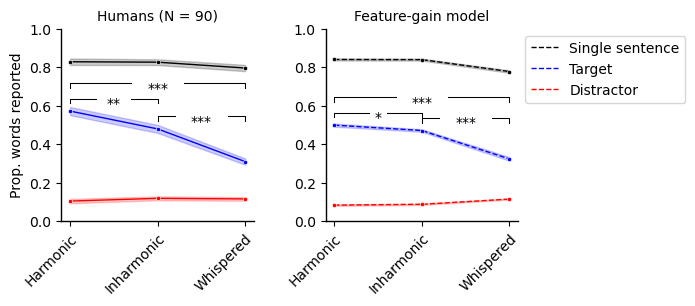

In [30]:
# def draw_stats_bar(ax, x1, x2, y, h, th=0.025, lw=1.5, col='k', fontsize=10):
#     ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=lw, c=col)
#     # edit so star is in middle of bar
#     ax.text((x1+x2)*.5, y+ th, "*", ha='center', va='center', color=col, fontsize=fontsize)

def draw_stats_bar(ax, x1, x2, y, h, text, th=0.025, lw=1.5, col='k', fontsize=10, text_gap=0.02):
    # Calculate the position of the text
    text_x = (x1 + x2) * 0.5
    text_y = y + th
    
    # Calculate the gap around the text
    gap_half_width = text_gap * len(text) # * (x2 - x1) * 0.5
    
    # Draw the left part of the bar
    ax.plot([x1, x1, text_x - gap_half_width], [y, y + h, y + h], lw=lw, c=col)
    
    # Draw the right part of the bar
    ax.plot([text_x + gap_half_width, x2, x2], [y + h, y + h, y], lw=lw, c=col)
    
    # Draw the text in the middle of the bar
    ax.text(text_x, y, text, ha='center', va='center', color=col, fontsize=fontsize)

# groups_to_plot = ['Humans (N = 90)', 'Feature-gain Model', 'Feature-gain Model New']
# groups_to_plot = ['Humans (N = 90)', 'v08 model', '50Hz cutoff', 'v09 model']
# groups_to_plot = ['Humans (N = 90)', 'Feature-gain model', 'Conventional Layer Order', '50Hz cutoff model']
groups_to_plot = melted_results.group.unique()

n_models = len(groups_to_plot)

to_plot = melted_results[melted_results.group.isin(groups_to_plot)]
to_plot = to_plot[(to_plot.target_harmonicity == to_plot.distractor_harmonicity) | (to_plot.distractor_harmonicity == 'No Distractor')]
no_dist_IXS = to_plot[to_plot.distractor_harmonicity == 'No Distractor'].index.values
to_plot.loc[no_dist_IXS, 'distractor_harmonicity'] = to_plot.loc[no_dist_IXS, 'target_harmonicity'] 
to_plot =to_plot[to_plot.distractor_harmonicity != 'No Distractor']

hues = ['k', 'b', 'r']
hue_order = ['Single sentence', 'Target', 'Distractor']

palette = {'Target': 'b', 'Distractor': 'r', 'Single sentence': 'k'}

fontsize=10
tick_fontsize = 10
# fontsize = 10
err_band_alpha = 0.2

yticks = np.linspace(0,1,6).round(1)

xtick_labels = to_plot.distractor_harmonicity.unique()
xticks = np.arange(len(xtick_labels))
ratio = 1.0 
line_thickness = 1


aspect = 2.5
fig, axs = plt.subplots(1, n_models, figsize=((aspect) * (n_models + .5), aspect ))


for ax, model in zip(axs, groups_to_plot):
    sns.lineplot(data=to_plot[to_plot.group == model],  x='distractor_harmonicity', y='hits', 
                hue = 'attended_stream', hue_order=hue_order,
                palette=hues,
                ax=ax,
                errorbar=('se', 1), err_style='band', err_kws={'alpha':err_band_alpha},
                marker='.', 
                 )
    ax.set_title(model, fontsize=fontsize)
    ax.set_xlabel('')
    ax.set_ylim(0,1)
    ax.set_yticks(np.linspace(0,1,6).round(1))
    ax.set_xticklabels(xtick_labels, rotation=45, fontsize=tick_fontsize, ha='right', rotation_mode='anchor')
    xleft, xright = ax.get_xlim()
    ybottom, ytop = ax.get_ylim()
    ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)
    for line in ax.get_lines():
    #     line.set_markerfacecolor(line.get_color())
    #     line.set_markeredgecolor('w')
        line.set_linewidth(1)
        line.set_markersize(6)
        line.set_markeredgewidth(.4)
        if model != groups_to_plot[0]:
            line.set_linestyle('--')

    # set line thickness for pannel
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(line_thickness)
        ax.spines[axis].set_color('k')


## Add p-values to plot

# set up x and y positions for p-value text
x_coord_dict = {'Harmonic_Inharmonic': {'x1': 0, 'x2': 1},
                'Harmonic_Whispered': {'x1': 0, 'x2': 2},
                'Inharmonic_Whispered': {'x1': 1, 'x2': 2}}

# get y_pos for p-value text for target stream from data
group_max = to_plot[(to_plot.attended_stream == 'Target') & (to_plot.distractor_harmonicity == 'Harmonic')].groupby(['group']).hits.mean()
inharmonic_max = to_plot[(to_plot.attended_stream == 'Target') & (to_plot.distractor_harmonicity == 'Inharmonic')].groupby(['group']).hits.mean()
h = 0.025
ver_shift_increment = 0.04

for ax, model in zip(axs, groups_to_plot):
    for stream in to_plot.attended_stream.unique():
        if stream != 'Target':
            continue
        for h_shift, harm_combo in enumerate(['Harmonic_Inharmonic', 'Inharmonic_Whispered', "Harmonic_Whispered"]):
            #get lead condition from str for x coordinate position
            first_cond, second_cond = harm_combo.split('_')
            # print(model)
            p_val = p_vals_df[(p_vals_df.group == model) & (p_vals_df.attended_stream == stream) & (p_vals_df.test == harm_combo)].p_val.values[0]
            if p_val < 0.05:
                text = "*"
                if p_val < 0.01:
                    text = "**"
                if p_val < 0.001:
                    text = "***"
                x1 = x_coord_dict[harm_combo]['x1']
                x2 = x_coord_dict[harm_combo]['x2']
                ver_shift = ver_shift_increment * (h_shift + 1) 
                if harm_combo == 'Inharmonic_Whispered':
                    y = inharmonic_max[model] + ver_shift_increment
                else:
                    y = group_max[model] + ver_shift
                draw_stats_bar(ax, x1, x2, y, h, text, col='k', lw=0.75, fontsize=fontsize, text_gap=0.1)
                
sns.despine()
# turn off axs[0] legend 
# axs[0].legend().remove()
# axs[1].legend().remove()
# axs[0].set_ylabel("Prop. target word", fontsize=fontsize)
# axs[1].set_ylabel("", fontsize=fontsize)
# axs[2].set_ylabel("", fontsize=fontsize)

# # move axs[1] legend 
# axs[2].legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=fontsize)
# # plt.subplots_adjust(wspace=0.5)

for ix in range(n_models-1):
    axs[ix].legend().remove()

axs[0].set_ylabel("Prop. words reported", fontsize=fontsize)
for ix in range(1, n_models):
    axs[ix].set_ylabel("", fontsize=fontsize)

# move axs[1] legend 
axs[-1].legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=fontsize)

# plt.tight_layout()
# plt.savefig(outfig_dest/'popham_conds.pdf', transparent=True, bbox_inches='tight')
